In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
df = pd.read_csv("../data/ipl.csv")
df.head()

C:\Users\sanga\AppData\Local\Temp\ipykernel_5280\385329361.py:1: DtypeWarning: Columns (0: review_batter, 1: team_reviewed, 2: review_decision, 3: umpire, 4: season, 5: superover_winner, 6: result_type, 7: method, 8: event_match_no) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/ipl.csv")


,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,ball_no,...,team_balls,team_wicket,new_batter,power_surge_start,batter_runs,batter_balls,bowler_wicket,batting_partners,striker_out,next_batter
0,335982,18-04-2008,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,0.1,...,1,0,NaN,NaN,0,1,0,BB McCullum|SC Ganguly,0,NaN
1,335982,18-04-2008,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,0.2,...,2,0,NaN,NaN,0,1,0,BB McCullum|SC Ganguly,0,NaN
2,335982,18-04-2008,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,0.3,...,2,0,NaN,NaN,0,1,0,BB McCullum|SC Ganguly,0,NaN
3,335982,18-04-2008,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,0.3,...,3,0,NaN,NaN,0,2,0,BB McCullum|SC Ganguly,0,NaN
4,335982,18-04-2008,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,0.4,...,4,0,NaN,NaN,0,3,0,BB McCullum|SC Ganguly,0,NaN


In [3]:
df.shape

(295732, 64)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 295732 entries, 0 to 295731
Data columns (total 64 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   match_id           295732 non-null  int64  
 1   date               295732 non-null  str    
 2   match_type         295732 non-null  str    
 3   event_name         295732 non-null  str    
 4   innings            295732 non-null  int64  
 5   batting_team       295732 non-null  str    
 6   bowling_team       295732 non-null  str    
 7   over               295732 non-null  int64  
 8   ball               295732 non-null  int64  
 9   ball_no            295732 non-null  float64
 10  batter             295732 non-null  str    
 11  bat_pos            295732 non-null  int64  
 12  runs_batter        295732 non-null  int64  
 13  balls_faced        295732 non-null  int64  
 14  bowler             295732 non-null  str    
 15  valid_ball         295732 non-null  int64  
 16  runs_extras  

In [5]:
df.isnull().sum()


match_id                 0
date                     0
match_type               0
event_name               0
innings                  0
                     ...  
batter_balls             0
bowler_wicket            0
batting_partners         0
striker_out              0
next_batter         281569
Length: 64, dtype: int64

In [6]:
df["match_id"].nunique()

1243

In [7]:
df["event_name"].value_counts()

event_name
Indian Premier League    295732
Name: count, dtype: int64

In [8]:
[c for c in df.columns if "season" in c.lower()]
df["season"].value_counts()

df["season"].dtype
df["season"].map(type).value_counts()
sorted(df["season"].astype(str).unique())

df["season"] = df["season"].astype(str)
df["season"].map(type).value_counts()
df["season"].value_counts().sort_index()

season
2007/08    13489
2009       13606
2009/10    14498
2011       17013
2012       17767
2013       18177
2014       14300
2015       13652
2016       14096
2017       13862
2018       14286
2019       14312
2020/21    14559
2021       14425
2022       17912
2023       17863
2024       17103
2025       17285
2026       17527
Name: count, dtype: int64

In [9]:
df["batting_team"].unique()

<StringArray>
[      'Kolkata Knight Riders', 'Royal Challengers Bangalore',
         'Chennai Super Kings',             'Kings XI Punjab',
            'Rajasthan Royals',            'Delhi Daredevils',
              'Mumbai Indians',             'Deccan Chargers',
        'Kochi Tuskers Kerala',               'Pune Warriors',
         'Sunrisers Hyderabad',     'Rising Pune Supergiants',
               'Gujarat Lions',      'Rising Pune Supergiant',
              'Delhi Capitals',                'Punjab Kings',
        'Lucknow Super Giants',              'Gujarat Titans',
 'Royal Challengers Bengaluru']
Length: 19, dtype: str

In [10]:
df["win_outcome"].value_counts()

win_outcome
6 wickets    33237
7 wickets    30455
5 wickets    26905
8 wickets    20523
4 wickets    16021
             ...  
89 runs        215
138 runs       212
146 runs       211
76 runs        204
112 runs       189
Name: count, Length: 114, dtype: int64

In [11]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

power_surge_start    295732
team_reviewed        294742
review_batter        294742
review_decision      294742
umpire               294742
method               291601
superover_winner     291580
result_type          290752
fielders             285011
new_batter           281569
next_batter          281569
wicket_kind          281027
player_out           281027
extra_type           279505
runs_target          153429
win_outcome            4980
dtype: int64

In [12]:
df["batting_team"].nunique()

19

In [13]:
df["date"].min(), df["date"].max()

('01-04-2010', '31-10-2020')

In [14]:
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

In [15]:
df["date"].min(), df["date"].max()

(Timestamp('2008-04-18 00:00:00'), Timestamp('2026-05-31 00:00:00'))

In [16]:
df["season"].value_counts().sort_index()

season
2007/08    13489
2009       13606
2009/10    14498
2011       17013
2012       17767
2013       18177
2014       14300
2015       13652
2016       14096
2017       13862
2018       14286
2019       14312
2020/21    14559
2021       14425
2022       17912
2023       17863
2024       17103
2025       17285
2026       17527
Name: count, dtype: int64

In [17]:
matches = df.drop_duplicates("match_id").copy()
matches.shape

(1243, 64)

In [18]:
df.groupby("season")["date"].agg(["min", "max"])

,min,max
season,,
2007/08,2008-04-18,2008-06-01
2009,2009-04-18,2009-05-24
2009/10,2010-03-12,2010-04-25
2011,2011-04-08,2011-05-28
2012,2012-04-04,2012-05-27
2013,2013-04-03,2013-05-26
2014,2014-04-16,2014-06-01
2015,2015-04-08,2015-05-24
2016,2016-04-09,2016-05-29


In [19]:
# Check columns with unique values
df.nunique().sort_values()

power_surge_start       0
event_name              1
match_number            1
match_type              1
method                  1
                     ... 
batter                738
date                  947
fielders             1150
match_id             1243
batting_partners     5411
Length: 64, dtype: int64

In [20]:
# Identify columns containing only one unique value
df.nunique()[df.nunique() == 1]

match_type        1
event_name        1
gender            1
team_type         1
method            1
balls_per_over    1
overs             1
match_number      1
dtype: int64

In [21]:
# Check completely duplicated rows
df.duplicated().sum()

np.int64(0)

In [22]:
df["method"].unique()

<StringArray>
[nan, 'D/L']
Length: 2, dtype: str

In [23]:
df["power_surge_start"].unique()

array([nan])

In [24]:
df["match_type"].unique()

<StringArray>
['T20']
Length: 1, dtype: str

In [25]:
#cleaned dataset
df_clean = df.copy()
columns_to_remove = [
    "match_type",
    "event_name",
    "gender",
    "team_type",
    "balls_per_over",
    "overs",
    "match_number",
    "power_surge_start"
]

df_clean = df_clean.drop(columns=columns_to_remove)
df_clean.shape

(295732, 56)

In [26]:
missing = df_clean.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

team_reviewed       294742
review_batter       294742
review_decision     294742
umpire              294742
method              291601
superover_winner    291580
result_type         290752
fielders            285011
new_batter          281569
next_batter         281569
wicket_kind         281027
player_out          281027
extra_type          279505
runs_target         153429
win_outcome           4980
dtype: int64

In [27]:
df_clean["win_outcome"].value_counts(dropna=False)

win_outcome
6 wickets    33237
7 wickets    30455
5 wickets    26905
8 wickets    20523
4 wickets    16021
             ...  
89 runs        215
138 runs       212
146 runs       211
76 runs        204
112 runs       189
Name: count, Length: 115, dtype: int64

In [28]:
df_clean["result_type"].value_counts(dropna=False)

result_type
NaN          290752
tie            4152
no result       828
Name: count, dtype: int64

In [29]:
df_clean["method"].value_counts(dropna=False)

method
NaN    291601
D/L      4131
Name: count, dtype: int64

In [30]:
df_clean["wicket_kind"].value_counts(dropna=False)

wicket_kind
NaN                      281027
caught                     9321
bowled                     2460
run out                    1194
lbw                         883
caught and bowled           410
stumped                     388
hit wicket                   20
retired hurt                 19
retired out                   6
obstructing the field         4
Name: count, dtype: int64

In [31]:
match_check = df_clean.groupby("match_id").agg({
    "season": "nunique",
    "date": "nunique",
    "toss_winner": "nunique",
    "toss_decision": "nunique",
    "venue": "nunique",
    "match_won_by": "nunique",
    "result_type": "nunique"
})

match_check.describe()

,season,date,toss_winner,toss_decision,venue,match_won_by,result_type
count,1243.0,1243.0,1243.0,1243.0,1243.0,1243.0,1243.000000
mean,1.0,1.0,1.0,1.0,1.0,1.0,0.020113
std,0.0,0.0,0.0,0.0,0.0,0.0,0.140442
min,1.0,1.0,1.0,1.0,1.0,1.0,0.000000
25%,1.0,1.0,1.0,1.0,1.0,1.0,0.000000
50%,1.0,1.0,1.0,1.0,1.0,1.0,0.000000
75%,1.0,1.0,1.0,1.0,1.0,1.0,0.000000
max,1.0,1.0,1.0,1.0,1.0,1.0,1.000000


In [32]:
match_check[
    (match_check["season"] > 1) |
    (match_check["date"] > 1) |
    (match_check["toss_winner"] > 1) |
    (match_check["toss_decision"] > 1) |
    (match_check["venue"] > 1)
]

,season,date,toss_winner,toss_decision,venue,match_won_by,result_type
match_id,,,,,,,


In [33]:
matches = df_clean.groupby("match_id").agg({
    "season": "first",
    "date": "first",
    "toss_winner": "first",
    "toss_decision": "first",
    "venue": "first",
    "city": "first",
    "match_won_by": "first",
    "win_outcome": "first",
    "result_type": "first",
    "method": "first"
}).reset_index()

In [34]:
matches.shape

(1243, 11)

In [35]:
matches.head()

,match_id,season,date,toss_winner,toss_decision,venue,city,match_won_by,win_outcome,result_type,method
0,335982,2007/08,2008-04-18,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,Kolkata Knight Riders,140 runs,NaN,NaN
1,335983,2007/08,2008-04-19,Chennai Super Kings,bat,"Punjab Cricket Association Stadium, Mohali",Chandigarh,Chennai Super Kings,33 runs,NaN,NaN
2,335984,2007/08,2008-04-19,Rajasthan Royals,bat,Feroz Shah Kotla,Delhi,Delhi Daredevils,9 wickets,NaN,NaN
3,335985,2007/08,2008-04-20,Mumbai Indians,bat,Wankhede Stadium,Mumbai,Royal Challengers Bangalore,5 wickets,NaN,NaN
4,335986,2007/08,2008-04-20,Deccan Chargers,bat,Eden Gardens,Kolkata,Kolkata Knight Riders,5 wickets,NaN,NaN


In [36]:
teams_per_match = df_clean.groupby("match_id").agg({
    "batting_team": "nunique",
    "bowling_team": "nunique"
})

teams_per_match.head()

,batting_team,bowling_team
match_id,,
335982,2,2
335983,2,2
335984,2,2
335985,2,2
335986,2,2


In [37]:
#differentiating two teams
teams = (
    pd.concat([
        df_clean[["match_id", "batting_team"]]
        .rename(columns={"batting_team": "team"}),

        df_clean[["match_id", "bowling_team"]]
        .rename(columns={"bowling_team": "team"})
    ])
    .drop_duplicates()
)

In [38]:
teams.head()

,match_id,team
0,335982,Kolkata Knight Riders
124,335982,Royal Challengers Bangalore
225,335983,Chennai Super Kings
349,335983,Kings XI Punjab
473,335984,Rajasthan Royals


In [39]:
teams = (
    teams.groupby("match_id")["team"]
    .apply(list)
    .reset_index()
)

In [40]:
teams["team1"] = teams["team"].apply(lambda x: x[0])
teams["team2"] = teams["team"].apply(lambda x: x[1])

In [41]:
teams = teams.drop(columns=["team"])

In [42]:
teams.head()

,match_id,team1,team2
0,335982,Kolkata Knight Riders,Royal Challengers Bangalore
1,335983,Chennai Super Kings,Kings XI Punjab
2,335984,Rajasthan Royals,Delhi Daredevils
3,335985,Mumbai Indians,Royal Challengers Bangalore
4,335986,Deccan Chargers,Kolkata Knight Riders


In [43]:
matches = df_clean.groupby("match_id").agg({
    "season": "first",
    "date": "first",
    "toss_winner": "first",
    "toss_decision": "first",
    "venue": "first",
    "city": "first",
    "match_won_by": "first",
    "win_outcome": "first",
    "result_type": "first",
    "method": "first"
}).reset_index()

In [44]:
matches = matches.merge(
    teams,
    on="match_id",
    how="left"
)

In [45]:
matches.shape

(1243, 13)

In [46]:
matches.head()

,match_id,season,date,toss_winner,toss_decision,venue,city,match_won_by,win_outcome,result_type,method,team1,team2
0,335982,2007/08,2008-04-18,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,Kolkata Knight Riders,140 runs,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
1,335983,2007/08,2008-04-19,Chennai Super Kings,bat,"Punjab Cricket Association Stadium, Mohali",Chandigarh,Chennai Super Kings,33 runs,NaN,NaN,Chennai Super Kings,Kings XI Punjab
2,335984,2007/08,2008-04-19,Rajasthan Royals,bat,Feroz Shah Kotla,Delhi,Delhi Daredevils,9 wickets,NaN,NaN,Rajasthan Royals,Delhi Daredevils
3,335985,2007/08,2008-04-20,Mumbai Indians,bat,Wankhede Stadium,Mumbai,Royal Challengers Bangalore,5 wickets,NaN,NaN,Mumbai Indians,Royal Challengers Bangalore
4,335986,2007/08,2008-04-20,Deccan Chargers,bat,Eden Gardens,Kolkata,Kolkata Knight Riders,5 wickets,NaN,NaN,Deccan Chargers,Kolkata Knight Riders


In [47]:
matches["match_won_by"].value_counts(dropna=False)

match_won_by
Mumbai Indians                 155
Chennai Super Kings            148
Kolkata Knight Riders          140
Rajasthan Royals               123
Royal Challengers Bangalore    114
Sunrisers Hyderabad            102
Kings XI Punjab                 85
Delhi Daredevils                67
Delhi Capitals                  58
Gujarat Titans                  47
Punjab Kings                    41
Lucknow Super Giants            34
Deccan Chargers                 29
Royal Challengers Bengaluru     29
Unknown                         25
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64

In [48]:
matches["match_won_by"].isna().sum()

np.int64(0)

In [49]:
matches["winner"] = matches["match_won_by"]

In [50]:
matches[["match_id", "team1", "team2", "winner"]].head(10)

,match_id,team1,team2,winner
0,335982,Kolkata Knight Riders,Royal Challengers Bangalore,Kolkata Knight Riders
1,335983,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings
2,335984,Rajasthan Royals,Delhi Daredevils,Delhi Daredevils
3,335985,Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore
4,335986,Deccan Chargers,Kolkata Knight Riders,Kolkata Knight Riders
5,335987,Kings XI Punjab,Rajasthan Royals,Rajasthan Royals
6,335988,Deccan Chargers,Delhi Daredevils,Delhi Daredevils
7,335989,Chennai Super Kings,Mumbai Indians,Chennai Super Kings
8,335990,Deccan Chargers,Rajasthan Royals,Rajasthan Royals
9,335991,Kings XI Punjab,Mumbai Indians,Kings XI Punjab


In [51]:
matches["winner_valid"] = (
    (matches["winner"] == matches["team1"]) |
    (matches["winner"] == matches["team2"]) |
    (matches["winner"] == "Unknown")
)

In [52]:
matches["winner_valid"].value_counts()

winner_valid
True    1243
Name: count, dtype: int64

In [53]:
matches[matches["winner"] == "Unknown"]

,match_id,season,date,toss_winner,toss_decision,venue,city,match_won_by,win_outcome,result_type,method,team1,team2,winner,winner_valid
66,392190,2009,2009-04-23,Kolkata Knight Riders,field,Newlands,Cape Town,Unknown,NaN,tie,NaN,Rajasthan Royals,Kolkata Knight Riders,Unknown,True
130,419121,2009/10,2010-03-21,Chennai Super Kings,field,"MA Chidambaram Stadium, Chepauk",Chennai,Unknown,NaN,tie,NaN,Kings XI Punjab,Chennai Super Kings,Unknown,True
241,501265,2011,2011-05-21,Delhi Daredevils,bat,Feroz Shah Kotla,Delhi,Unknown,NaN,no result,NaN,Delhi Daredevils,Pune Warriors,Unknown,True
328,598004,2013,2013-04-07,Royal Challengers Bangalore,bat,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Unknown,NaN,tie,NaN,Royal Challengers Bangalore,Sunrisers Hyderabad,Unknown,True
341,598017,2013,2013-04-16,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,Unknown,NaN,tie,NaN,Delhi Daredevils,Royal Challengers Bangalore,Unknown,True
416,729315,2014,2014-04-29,Rajasthan Royals,bat,Sheikh Zayed Stadium,Abu Dhabi,Unknown,NaN,tie,NaN,Rajasthan Royals,Kolkata Knight Riders,Unknown,True
476,829741,2015,2015-04-21,Kings XI Punjab,field,"Sardar Patel Stadium, Motera",Ahmedabad,Unknown,NaN,tie,NaN,Rajasthan Royals,Kings XI Punjab,Unknown,True
486,829763,2015,2015-04-29,Rajasthan Royals,field,M Chinnaswamy Stadium,Bangalore,Unknown,NaN,no result,NaN,Royal Challengers Bangalore,Rajasthan Royals,Unknown,True
511,829813,2015,2015-05-17,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,Unknown,NaN,no result,NaN,Delhi Daredevils,Royal Challengers Bangalore,Unknown,True
610,1082625,2017,2017-04-29,Gujarat Lions,bat,Saurashtra Cricket Association Stadium,Rajkot,Unknown,NaN,tie,NaN,Gujarat Lions,Mumbai Indians,Unknown,True


In [54]:
#team wins analytical data
team_wins = (
    matches[matches["winner"] != "Unknown"]
    ["winner"]
    .value_counts()
    .reset_index()
)

In [55]:
team_wins.columns = ["team", "wins"]
print(team_wins)

                           team  wins
0                Mumbai Indians   155
1           Chennai Super Kings   148
2         Kolkata Knight Riders   140
3              Rajasthan Royals   123
4   Royal Challengers Bangalore   114
5           Sunrisers Hyderabad   102
6               Kings XI Punjab    85
7              Delhi Daredevils    67
8                Delhi Capitals    58
9                Gujarat Titans    47
10                 Punjab Kings    41
11         Lucknow Super Giants    34
12              Deccan Chargers    29
13  Royal Challengers Bengaluru    29
14                Gujarat Lions    13
15                Pune Warriors    12
16       Rising Pune Supergiant    10
17         Kochi Tuskers Kerala     6
18      Rising Pune Supergiants     5


In [56]:
#winner btn matches
team_matches = pd.concat([
    matches[["match_id", "team1", "winner"]]
        .rename(columns={"team1": "team"}),

    matches[["match_id", "team2", "winner"]]
        .rename(columns={"team2": "team"})
])

In [57]:
team_matches.head()

,match_id,team,winner
0,335982,Kolkata Knight Riders,Kolkata Knight Riders
1,335983,Chennai Super Kings,Chennai Super Kings
2,335984,Rajasthan Royals,Delhi Daredevils
3,335985,Mumbai Indians,Royal Challengers Bangalore
4,335986,Deccan Chargers,Kolkata Knight Riders


In [58]:
#matches played
matches_played = (
    team_matches
    .groupby("team")["match_id"]
    .nunique()
    .reset_index()
)

In [59]:
matches_played.columns = ["team", "matches_played"]

In [60]:
matches_played.sort_values(
    "matches_played",
    ascending=False
)

,team,matches_played
10,Mumbai Indians,291
8,Kolkata Knight Riders,278
0,Chennai Super Kings,266
13,Rajasthan Royals,251
16,Royal Challengers Bangalore,240
18,Sunrisers Hyderabad,211
6,Kings XI Punjab,190
3,Delhi Daredevils,161
2,Delhi Capitals,120
12,Punjab Kings,88


In [61]:
#combining those two results
team_stats = matches_played.merge(
    team_wins,
    on="team",
    how="left"
)

In [62]:
team_stats["wins"] = team_stats["wins"].fillna(0)

In [63]:
team_stats["win_percentage"] = (
    team_stats["wins"] /
    team_stats["matches_played"] * 100
)

In [64]:
team_stats = team_stats.sort_values(
    "win_percentage",
    ascending=False
)

In [65]:
#displying
team_wins = (
    matches[matches["winner"] != "Unknown"]
    ["winner"]
    .value_counts()
    .reset_index()
)

team_wins.columns = ["team", "wins"]

In [66]:
team_matches = pd.concat([
    matches[["match_id", "team1", "winner"]]
        .rename(columns={"team1": "team"}),

    matches[["match_id", "team2", "winner"]]
        .rename(columns={"team2": "team"})
])

In [67]:
matches_played = (
    team_matches
    .groupby("team")["match_id"]
    .nunique()
    .reset_index()
)

matches_played.columns = ["team", "matches_played"]

In [68]:
matches_played.sort_values("matches_played", ascending=False)

,team,matches_played
10,Mumbai Indians,291
8,Kolkata Knight Riders,278
0,Chennai Super Kings,266
13,Rajasthan Royals,251
16,Royal Challengers Bangalore,240
18,Sunrisers Hyderabad,211
6,Kings XI Punjab,190
3,Delhi Daredevils,161
2,Delhi Capitals,120
12,Punjab Kings,88


In [69]:
#standardize team name
team_name_mapping = {
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru",
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings",
    "Rising Pune Supergiant": "Rising Pune Supergiants"
}

In [70]:
matches["team1"] = matches["team1"].replace(team_name_mapping)
matches["team2"] = matches["team2"].replace(team_name_mapping)
matches["winner"] = matches["winner"].replace(team_name_mapping)
matches["toss_winner"] = matches["toss_winner"].replace(team_name_mapping)

In [71]:
#recreate team matches
team_matches = pd.concat([
    matches[["match_id", "team1", "winner"]]
        .rename(columns={"team1": "team"}),

    matches[["match_id", "team2", "winner"]]
        .rename(columns={"team2": "team"})
])

In [72]:
matches_played = (
    team_matches
    .groupby("team")["match_id"]
    .nunique()
    .reset_index()
)

matches_played.columns = ["team", "matches_played"]

In [73]:
team_wins = (
    matches[matches["winner"] != "Unknown"]
    ["winner"]
    .value_counts()
    .reset_index()
)

team_wins.columns = ["team", "wins"]

In [74]:
team_stats = matches_played.merge(
    team_wins,
    on="team",
    how="left"
)

In [75]:
team_stats["wins"] = team_stats["wins"].fillna(0)

In [76]:
team_stats["win_percentage"] = (
    team_stats["wins"] /
    team_stats["matches_played"] * 100
)

In [77]:
team_stats = team_stats.sort_values(
    "win_percentage",
    ascending=False
)

In [78]:
print(team_stats)

                           team  matches_played  wins  win_percentage
4                Gujarat Titans              77    47       61.038961
0           Chennai Super Kings             266   148       55.639098
8                Mumbai Indians             291   155       53.264605
6         Kolkata Knight Riders             278   140       50.359712
12      Rising Pune Supergiants              30    15       50.000000
13  Royal Challengers Bengaluru             286   143       50.000000
11             Rajasthan Royals             251   123       49.003984
14          Sunrisers Hyderabad             211   102       48.341232
7          Lucknow Super Giants              72    34       47.222222
10                 Punjab Kings             278   126       45.323741
2                Delhi Capitals             281   125       44.483986
3                 Gujarat Lions              30    13       43.333333
5          Kochi Tuskers Kerala              14     6       42.857143
1               Decc

In [79]:
team_stats_50 = team_stats[
    team_stats["matches_played"] >= 50
].copy()

In [80]:
team_stats_50 = team_stats_50.sort_values(
    "win_percentage",
    ascending=False
)

In [81]:
print(team_stats_50)

                           team  matches_played  wins  win_percentage
4                Gujarat Titans              77    47       61.038961
0           Chennai Super Kings             266   148       55.639098
8                Mumbai Indians             291   155       53.264605
6         Kolkata Knight Riders             278   140       50.359712
13  Royal Challengers Bengaluru             286   143       50.000000
11             Rajasthan Royals             251   123       49.003984
14          Sunrisers Hyderabad             211   102       48.341232
7          Lucknow Super Giants              72    34       47.222222
10                 Punjab Kings             278   126       45.323741
2                Delhi Capitals             281   125       44.483986
1               Deccan Chargers              75    29       38.666667


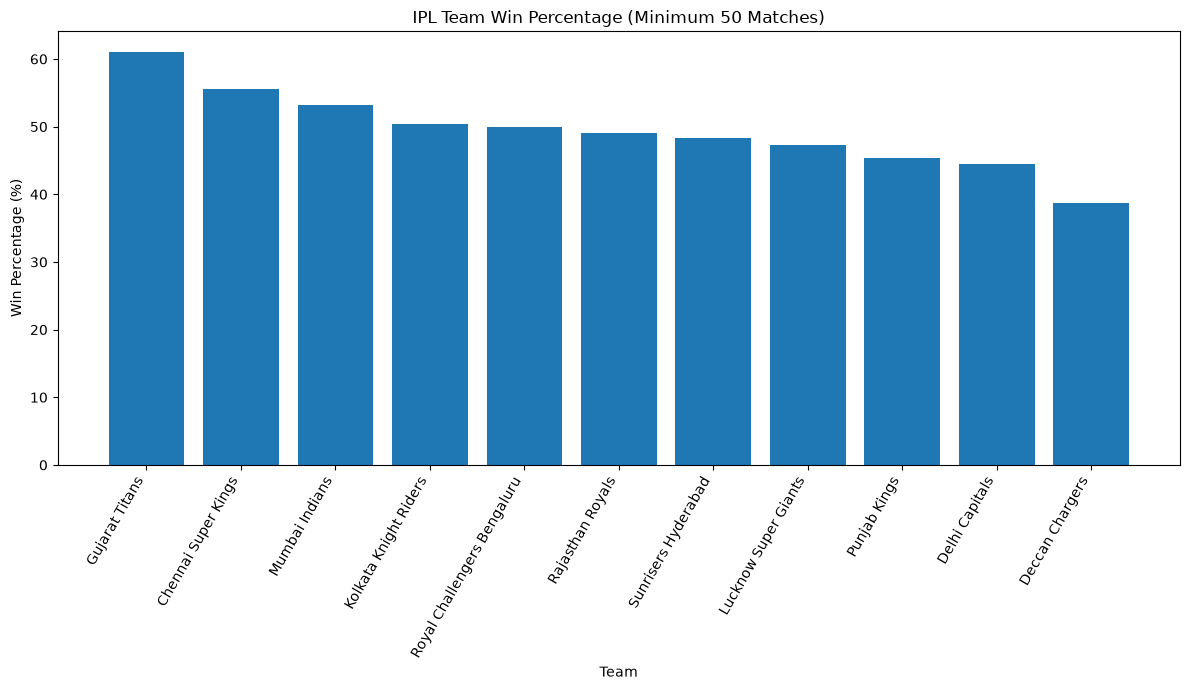

In [82]:
#chart of winning teams

plt.figure(figsize=(12, 7))

plt.bar(
    team_stats_50["team"],
    team_stats_50["win_percentage"]
)

plt.title("IPL Team Win Percentage (Minimum 50 Matches)")
plt.xlabel("Team")
plt.ylabel("Win Percentage (%)")

plt.xticks(rotation=60, ha="right")

plt.tight_layout()
plt.show()

In [83]:
#performance changed by seassons

season_matches = (
    matches.groupby("season")["match_id"]
    .nunique()
    .reset_index()
)

season_matches.columns = ["season", "matches"]

In [84]:
print(season_matches)

     season  matches
0   2007/08       58
1      2009       57
2   2009/10       60
3      2011       73
4      2012       74
5      2013       76
6      2014       60
7      2015       59
8      2016       60
9      2017       59
10     2018       60
11     2019       60
12  2020/21       60
13     2021       60
14     2022       74
15     2023       74
16     2024       71
17     2025       74
18     2026       74


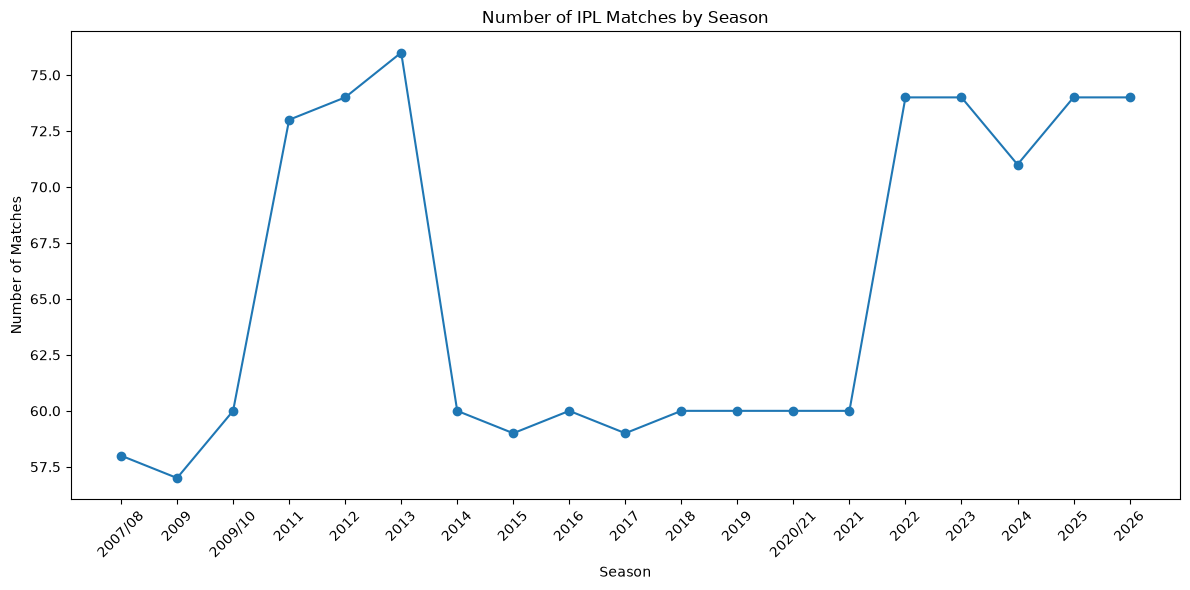

In [85]:
#series chart

plt.figure(figsize=(12, 6))

plt.plot(
    season_matches["season"].astype(str),
    season_matches["matches"],
    marker="o"
)

plt.title("Number of IPL Matches by Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [86]:
#runs per season

season_runs = (
    df_clean.groupby("season")["runs_total"]
    .sum()
    .reset_index()
)

In [87]:
season_runs.columns = ["season", "total_runs"]

In [88]:
print(season_runs)

     season  total_runs
0   2007/08       17937
1      2009       16353
2   2009/10       18883
3      2011       21154
4      2012       22453
5      2013       22602
6      2014       18931
7      2015       18353
8      2016       18862
9      2017       18786
10     2018       19901
11     2019       19434
12  2020/21       19416
13     2021       18637
14     2022       24395
15     2023       25688
16     2024       25971
17     2025       26527
18     2026       27455


In [89]:
#combine matches and runs
season_analysis = season_matches.merge(
    season_runs,
    on="season",
    how="left"
)

In [90]:
season_analysis["runs_per_match"] = (
    season_analysis["total_runs"] /
    season_analysis["matches"]
)

In [91]:
print(season_analysis)

     season  matches  total_runs  runs_per_match
0   2007/08       58       17937      309.258621
1      2009       57       16353      286.894737
2   2009/10       60       18883      314.716667
3      2011       73       21154      289.780822
4      2012       74       22453      303.418919
5      2013       76       22602      297.394737
6      2014       60       18931      315.516667
7      2015       59       18353      311.067797
8      2016       60       18862      314.366667
9      2017       59       18786      318.406780
10     2018       60       19901      331.683333
11     2019       60       19434      323.900000
12  2020/21       60       19416      323.600000
13     2021       60       18637      310.616667
14     2022       74       24395      329.662162
15     2023       74       25688      347.135135
16     2024       71       25971      365.788732
17     2025       74       26527      358.472973
18     2026       74       27455      371.013514


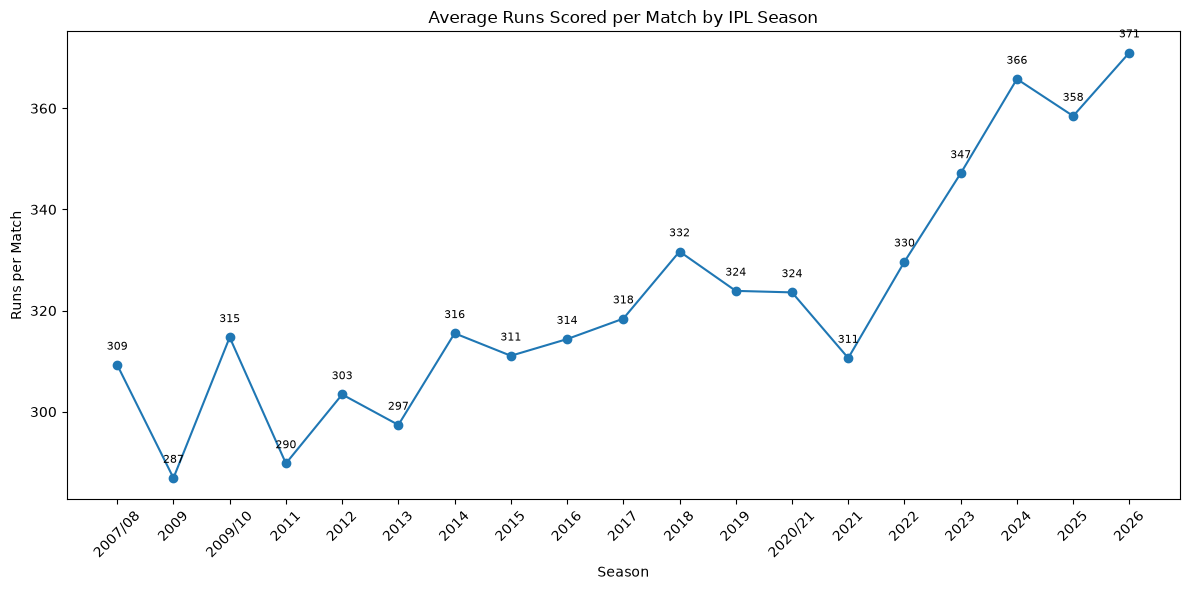

In [92]:
plt.figure(figsize=(12, 6))

plt.plot(
    season_analysis["season"].astype(str),
    season_analysis["runs_per_match"],
    marker="o"
)

for i, value in enumerate(season_analysis["runs_per_match"]):
    plt.text(
        i,
        value + 3,
        f"{value:.0f}",
        ha="center",
        fontsize=8
    )

plt.title("Average Runs Scored per Match by IPL Season")
plt.xlabel("Season")
plt.ylabel("Runs per Match")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [93]:
#player performance analysis

batter_runs = (
    df_clean.groupby("batter")["runs_batter"]
    .sum()
    .reset_index()
)

batter_runs.columns = ["batter", "total_runs"]

batter_runs = batter_runs.sort_values(
    "total_runs",
    ascending=False
)

batter_runs.head(10)

,batter,total_runs
693,V Kohli,9346
526,RG Sharma,7331
563,S Dhawan,6769
159,DA Warner,6567
311,KL Rahul,5828
597,SK Raina,5536
409,MS Dhoni,5439
52,AM Rahane,5367
31,AB de Villiers,5181
627,SV Samson,5181


In [94]:
batter_balls = (
    df_clean.groupby("batter")["balls_faced"]
    .sum()
    .reset_index()
)

batter_balls.columns = ["batter", "balls_faced"]

In [95]:
batter_stats = batter_runs.merge(
    batter_balls,
    on="batter",
    how="left"
)

In [96]:
batter_stats.head(10)

,batter,total_runs,balls_faced
0,V Kohli,9346,6930
1,RG Sharma,7331,5517
2,S Dhawan,6769,5326
3,DA Warner,6567,4702
4,KL Rahul,5828,4188
5,SK Raina,5536,4046
6,MS Dhoni,5439,3957
7,AM Rahane,5367,4273
8,AB de Villiers,5181,3411
9,SV Samson,5181,3671


In [97]:
batter_stats["strike_rate"] = (
    batter_stats["total_runs"] /
    batter_stats["balls_faced"].replace(0, np.nan)
) * 100

In [98]:
top_batters = batter_stats.sort_values(
    "total_runs",
    ascending=False
).head(10)

top_batters

,batter,total_runs,balls_faced,strike_rate
0,V Kohli,9346,6930,134.862915
1,RG Sharma,7331,5517,132.880189
2,S Dhawan,6769,5326,127.093504
3,DA Warner,6567,4702,139.663973
4,KL Rahul,5828,4188,139.159503
5,SK Raina,5536,4046,136.826495
6,MS Dhoni,5439,3957,137.452616
7,AM Rahane,5367,4273,125.602621
8,AB de Villiers,5181,3411,151.890941
9,SV Samson,5181,3671,141.133206


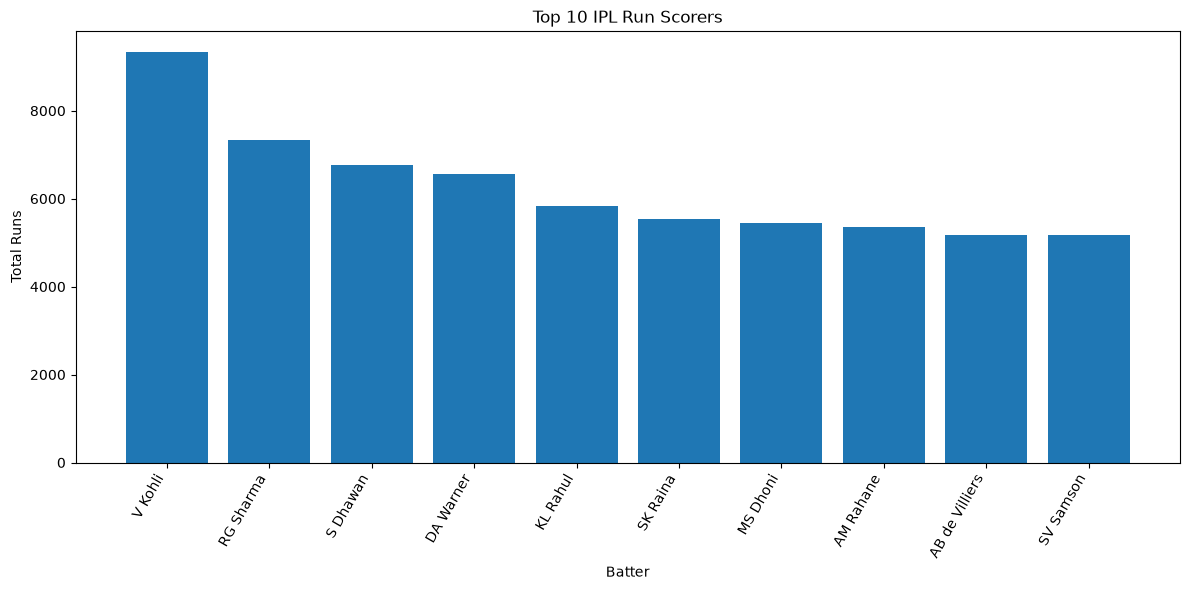

In [99]:
#chart for top batter

plt.figure(figsize=(12, 6))

plt.bar(
    top_batters["batter"],
    top_batters["total_runs"]
)

plt.title("Top 10 IPL Run Scorers")
plt.xlabel("Batter")
plt.ylabel("Total Runs")

plt.xticks(rotation=60, ha="right")

plt.tight_layout()
plt.show()

In [100]:
#bowling analysis

bowler_wicket_kinds = [
    "bowled",
    "caught",
    "lbw",
    "caught and bowled",
    "stumped",
    "hit wicket"
]

In [101]:
bowler_wickets = df_clean[
    df_clean["wicket_kind"].isin(bowler_wicket_kinds)
]

In [102]:
bowler_wickets.shape

(13482, 56)

In [103]:
bowler_stats = (
    bowler_wickets
    .groupby("bowler")
    .size()
    .reset_index(name="wickets")
)

In [104]:
bowler_stats = bowler_stats.sort_values(
    "wickets",
    ascending=False
)

In [105]:
top_bowlers = bowler_stats.head(10)

top_bowlers

,bowler,wickets
483,YS Chahal,233
65,B Kumar,226
409,SP Narine,209
321,PP Chawla,192
186,JJ Bumrah,190
331,R Ashwin,187
113,DJ Bravo,183
347,RA Jadeja,180
367,Rashid Khan,179
7,A Mishra,174


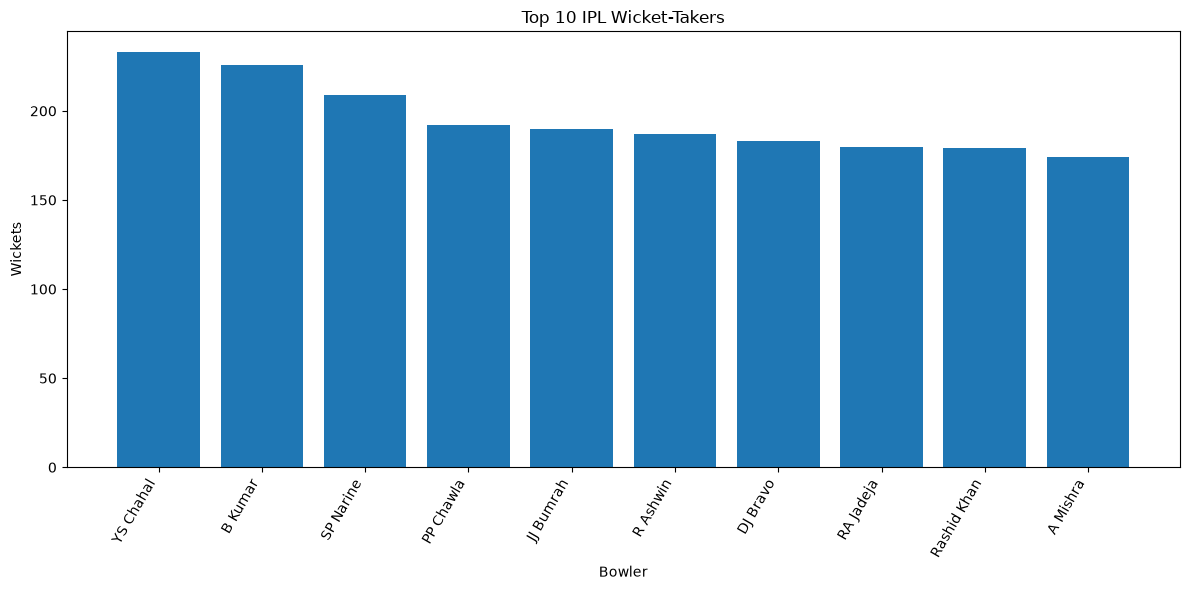

In [106]:
#chart of top bowler analysis
plt.figure(figsize=(12, 6))

plt.bar(
    top_bowlers["bowler"],
    top_bowlers["wickets"]
)

plt.title("Top 10 IPL Wicket-Takers")
plt.xlabel("Bowler")
plt.ylabel("Wickets")

plt.xticks(rotation=60, ha="right")

plt.tight_layout()
plt.show()

In [107]:
#toss won and also match won analysis

matches["toss_match_winner"] = (
    matches["toss_winner"] == matches["winner"]
)

In [108]:
toss_win_percentage = (
    matches["toss_match_winner"].mean() * 100
)

toss_win_percentage

np.float64(50.5229283990346)

In [109]:
toss_analysis = (
    matches.groupby("toss_decision")["toss_match_winner"]
    .mean()
    .reset_index()
)

toss_analysis["win_percentage"] = (
    toss_analysis["toss_match_winner"] * 100
)

toss_analysis

,toss_decision,toss_match_winner,win_percentage
0,bat,0.442584,44.258373
1,field,0.536970,53.696970


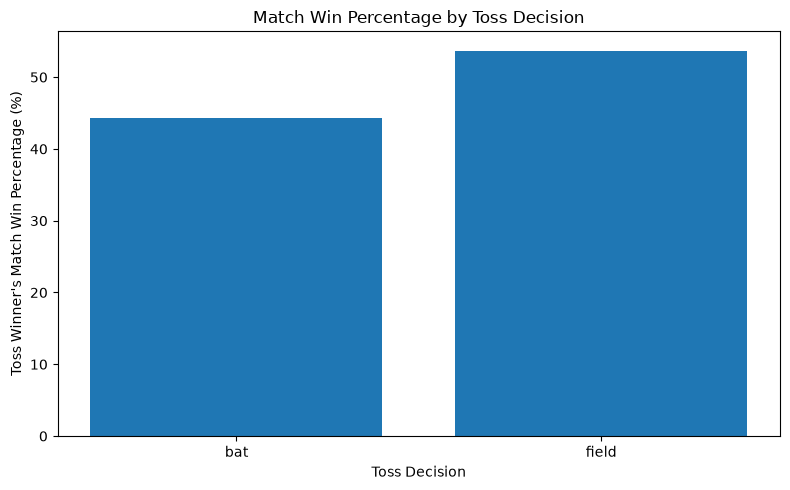

In [110]:
#chart of toss&win analysis

plt.figure(figsize=(8, 5))

plt.bar(
    toss_analysis["toss_decision"],
    toss_analysis["win_percentage"]
)

plt.title("Match Win Percentage by Toss Decision")
plt.xlabel("Toss Decision")
plt.ylabel("Toss Winner's Match Win Percentage (%)")

plt.tight_layout()
plt.show()

In [111]:
matches["toss_decision"].unique()

<StringArray>
['field', 'bat']
Length: 2, dtype: str

In [112]:
#venue analysis

venue_matches = (
    matches.groupby("venue")["match_id"]
    .nunique()
    .reset_index()
)

venue_matches.columns = ["venue", "matches"]

venue_matches = venue_matches.sort_values(
    "matches",
    ascending=False
)

venue_matches.head(10)

,venue,matches
14,Eden Gardens,77
57,Wankhede Stadium,73
23,M Chinnaswamy Stadium,65
16,Feroz Shah Kotla,60
58,"Wankhede Stadium, Mumbai",59
43,"Rajiv Gandhi International Stadium, Uppal",49
27,"MA Chidambaram Stadium, Chepauk",48
47,Sawai Mansingh Stadium,47
13,Dubai International Cricket Stadium,46
33,"Narendra Modi Stadium, Ahmedabad",41


In [113]:
venue_runs = (
    df_clean.groupby("venue")
    .agg(
        total_runs=("runs_total", "sum"),
        matches=("match_id", "nunique")
    )
    .reset_index()
)

In [114]:
venue_runs["runs_per_match"] = (
    venue_runs["total_runs"] /
    venue_runs["matches"]
)

In [115]:
venue_reliable = venue_runs[
    venue_runs["matches"] >= 20
].copy()

In [116]:
venue_reliable = venue_reliable.sort_values(
    "runs_per_match",
    ascending=False
)

In [117]:
venue_reliable.head(10)

,venue,total_runs,matches,runs_per_match
1,"Arun Jaitley Stadium, Delhi",11254,30,375.133333
48,"Sawai Mansingh Stadium, Jaipur",7829,21,372.809524
24,"M Chinnaswamy Stadium, Bengaluru",8930,24,372.083333
44,"Rajiv Gandhi International Stadium, Uppal, Hyd...",9605,26,369.423077
15,"Eden Gardens, Kolkata",10783,30,359.433333
58,"Wankhede Stadium, Mumbai",20853,59,353.440678
33,"Narendra Modi Stadium, Ahmedabad",14428,41,351.902439
4,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,9735,29,335.689655
10,"Dr DY Patil Sports Academy, Mumbai",6573,20,328.650000
28,"MA Chidambaram Stadium, Chepauk, Chennai",13348,41,325.560976


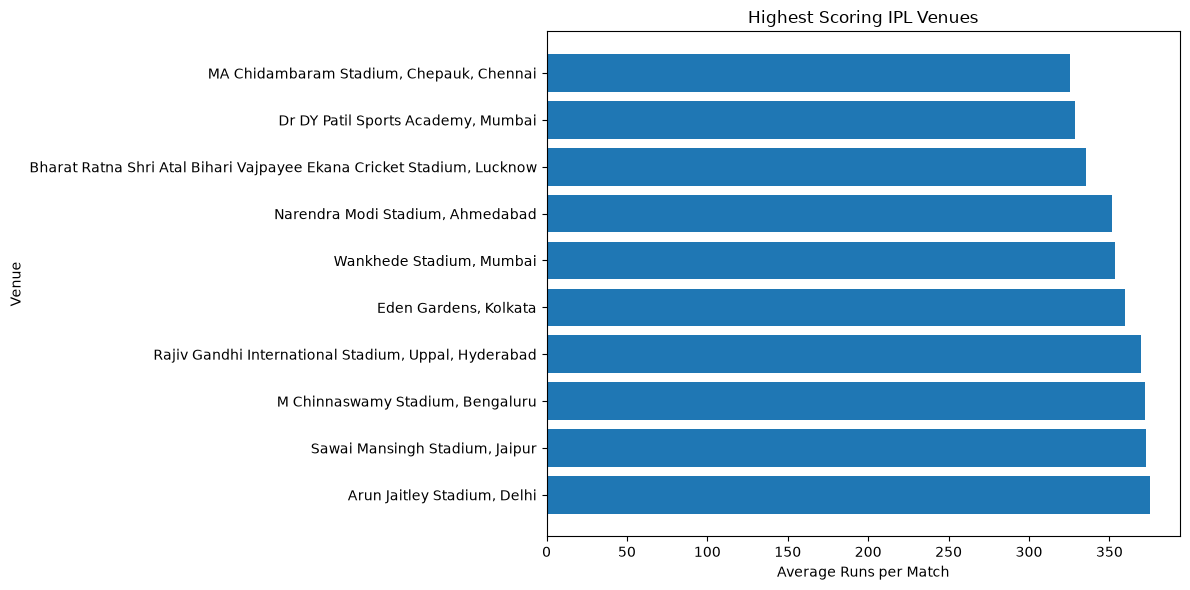

In [118]:
#chart for venue analysis
top_scoring_venues = venue_reliable.head(10)

plt.figure(figsize=(12, 6))

plt.barh(
    top_scoring_venues["venue"],
    top_scoring_venues["runs_per_match"]
)

plt.title("Highest Scoring IPL Venues")
plt.xlabel("Average Runs per Match")
plt.ylabel("Venue")

plt.tight_layout()
plt.show()

In [119]:
# ============================================
# FINAL DATASET FOR POWER BI
# ============================================

dashboard_columns = [
    "match_id",
    "date",
    "season",
    "innings",
    "batting_team",
    "bowling_team",
    "batter",
    "bowler",
    "runs_batter",
    "runs_total",
    "wicket_kind",
    "venue",
    "city",
    "toss_winner",
    "toss_decision",
    "match_won_by",
    "result_type",
    "method"
]

df_dashboard = df_clean[dashboard_columns].copy()

df_dashboard.head()

,match_id,date,season,innings,batting_team,bowling_team,batter,bowler,runs_batter,runs_total,wicket_kind,venue,city,toss_winner,toss_decision,match_won_by,result_type,method
0,335982,2008-04-18,2007/08,1,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,0,1,NaN,M Chinnaswamy Stadium,Bangalore,Royal Challengers Bangalore,field,Kolkata Knight Riders,NaN,NaN
1,335982,2008-04-18,2007/08,1,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,0,0,NaN,M Chinnaswamy Stadium,Bangalore,Royal Challengers Bangalore,field,Kolkata Knight Riders,NaN,NaN
2,335982,2008-04-18,2007/08,1,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,0,1,NaN,M Chinnaswamy Stadium,Bangalore,Royal Challengers Bangalore,field,Kolkata Knight Riders,NaN,NaN
3,335982,2008-04-18,2007/08,1,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,0,0,NaN,M Chinnaswamy Stadium,Bangalore,Royal Challengers Bangalore,field,Kolkata Knight Riders,NaN,NaN
4,335982,2008-04-18,2007/08,1,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,0,0,NaN,M Chinnaswamy Stadium,Bangalore,Royal Challengers Bangalore,field,Kolkata Knight Riders,NaN,NaN


In [120]:
df_dashboard.shape

(295732, 18)

In [121]:
df_dashboard.info()

<class 'pandas.DataFrame'>
RangeIndex: 295732 entries, 0 to 295731
Data columns (total 18 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   match_id       295732 non-null  int64         
 1   date           295732 non-null  datetime64[us]
 2   season         295732 non-null  str           
 3   innings        295732 non-null  int64         
 4   batting_team   295732 non-null  str           
 5   bowling_team   295732 non-null  str           
 6   batter         295732 non-null  str           
 7   bowler         295732 non-null  str           
 8   runs_batter    295732 non-null  int64         
 9   runs_total     295732 non-null  int64         
 10  wicket_kind    14705 non-null   str           
 11  venue          295732 non-null  str           
 12  city           295732 non-null  str           
 13  toss_winner    295732 non-null  str           
 14  toss_decision  295732 non-null  str           
 15  match_won_b

In [122]:
#dashboard clean-up
# Standardize team names for dashboard

team_mapping = {
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru",
    "Kings XI Punjab": "Punjab Kings",
    "Delhi Daredevils": "Delhi Capitals",
    "Deccan Chargers": "Deccan Chargers",
    "Rising Pune Supergiants": "Rising Pune Supergiant"
}

df_dashboard["batting_team_clean"] = (
    df_dashboard["batting_team"].replace(team_mapping)
)

df_dashboard["bowling_team_clean"] = (
    df_dashboard["bowling_team"].replace(team_mapping)
)

In [123]:
df_dashboard["batting_team_clean"].value_counts()

batting_team_clean
Mumbai Indians                 34990
Royal Challengers Bengaluru    33572
Delhi Capitals                 33107
Punjab Kings                   33100
Kolkata Knight Riders          32463
Chennai Super Kings            32101
Rajasthan Royals               29777
Sunrisers Hyderabad            25284
Gujarat Titans                  9379
Deccan Chargers                 9034
Lucknow Super Giants            8854
Pune Warriors                   5443
Gujarat Lions                   3566
Rising Pune Supergiant          3480
Kochi Tuskers Kerala            1582
Name: count, dtype: int64

In [124]:
df_dashboard["batting_team_clean"].nunique()

15

In [125]:
df_dashboard = df_dashboard.drop(
    columns=["batting_team", "bowling_team"]
)

df_dashboard = df_dashboard.rename(
    columns={
        "batting_team_clean": "batting_team",
        "bowling_team_clean": "bowling_team"
    }
)

In [126]:
df_dashboard.shape

(295732, 18)

In [127]:
df_dashboard.columns.tolist()

['match_id',
 'date',
 'season',
 'innings',
 'batter',
 'bowler',
 'runs_batter',
 'runs_total',
 'wicket_kind',
 'venue',
 'city',
 'toss_winner',
 'toss_decision',
 'match_won_by',
 'result_type',
 'method',
 'batting_team',
 'bowling_team']

In [128]:
# ============================================
# CREATE CLEAN DASHBOARD DATASET
# ============================================

df_clean = df.copy()

print("Original shape:", df_clean.shape)

Original shape: (295732, 64)


In [129]:
columns_to_remove = [
    "review_batter",
    "team_reviewed",
    "review_decision",
    "umpire",
    "player_of_match",
    "superover_winner",
    "event_match_no",
    "match_number",
    "new_batter",
    "power_surge_start",
    "batting_partners",
    "striker_out",
    "next_batter",
    "non_striker",
    "non_striker_pos",
    "fielders",
    "runs_not_boundary",
    "runs_bowler",
    "runs_not_boundary"
]

df_clean = df_clean.drop(
    columns=columns_to_remove,
    errors="ignore"
)

print("After removing unnecessary columns:", df_clean.shape)

After removing unnecessary columns: (295732, 46)


In [130]:
df_clean.shape

(295732, 46)

In [131]:
df_clean.dtypes

match_id                   int64
date              datetime64[us]
match_type                   str
event_name                   str
innings                    int64
batting_team                 str
bowling_team                 str
over                       int64
ball                       int64
ball_no                  float64
batter                       str
bat_pos                    int64
runs_batter                int64
balls_faced                int64
bowler                       str
valid_ball                 int64
runs_extras                int64
runs_total                 int64
extra_type                   str
wicket_kind                  str
player_out                   str
runs_target              float64
umpires_call                bool
match_won_by                 str
win_outcome                  str
toss_winner                  str
toss_decision                str
venue                        str
city                         str
day                        int64
month     

In [132]:
df_clean.isnull().sum().sort_values(ascending=False).head(15)

method          291601
result_type     290752
wicket_kind     281027
player_out      281027
extra_type      279505
runs_target     153429
win_outcome       4980
bowling_team         0
match_id             0
date                 0
match_type           0
event_name           0
innings              0
batting_team         0
balls_faced          0
dtype: int64

In [133]:
df_clean["season"] = df_clean["season"].astype(str)

In [134]:
df_clean["season"].dtype

<StringDtype(storage='python', na_value=nan)>

In [135]:
team_mapping = {
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru",
    "Kings XI Punjab": "Punjab Kings",
    "Delhi Daredevils": "Delhi Capitals",
    "Rising Pune Supergiants": "Rising Pune Supergiant"
}

df_clean["batting_team"] = df_clean["batting_team"].replace(team_mapping)
df_clean["bowling_team"] = df_clean["bowling_team"].replace(team_mapping)

In [136]:
df_clean["batting_team"].nunique()

15

In [137]:
df_clean["batting_team"].unique()

<StringArray>
[      'Kolkata Knight Riders', 'Royal Challengers Bengaluru',
         'Chennai Super Kings',                'Punjab Kings',
            'Rajasthan Royals',              'Delhi Capitals',
              'Mumbai Indians',             'Deccan Chargers',
        'Kochi Tuskers Kerala',               'Pune Warriors',
         'Sunrisers Hyderabad',      'Rising Pune Supergiant',
               'Gujarat Lions',        'Lucknow Super Giants',
              'Gujarat Titans']
Length: 15, dtype: str

In [138]:
df_clean.duplicated().sum()

np.int64(0)

In [139]:
numeric_columns = [
    "match_id",
    "innings",
    "over",
    "ball",
    "ball_no",
    "bat_pos",
    "runs_batter",
    "balls_faced",
    "valid_ball",
    "runs_extras",
    "runs_total",
    "team_runs",
    "team_balls",
    "team_wicket",
    "batter_runs",
    "batter_balls",
    "bowler_wicket"
]

for col in numeric_columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

In [140]:
df_clean[numeric_columns].isnull().sum().sum()

np.int64(0)

In [141]:
print("Rows:", len(df_clean))
print("Columns:", len(df_clean.columns))
print("Duplicate rows:", df_clean.duplicated().sum())
print("Teams:", df_clean["batting_team"].nunique())
print("Seasons:", df_clean["season"].nunique())

Rows: 295732
Columns: 46
Duplicate rows: 0
Teams: 15
Seasons: 19


In [142]:
#clean dataset uploaded
import os

os.makedirs("../data", exist_ok=True)

df_clean.to_csv(
    "../data/IPL_Dashboard_Data.csv",
    index=False
)

print("Clean dataset exported successfully!")

Clean dataset exported successfully!


In [143]:
os.path.exists("../data/IPL_Dashboard_Data.csv")

True

In [144]:
df["season"] = df["season"].astype(str)

In [146]:
seasons = df["season"].dropna().unique().tolist()